# Crypto Volatility EDA
**Rizaldy Utomo**  
`rutomo@andrew.cmu.edu`

- This notebook profiles engineered one-second crypto volatility features.
- The goal is to inspect label balance, feature behavior, and threshold selection before modeling.
- Figures are exported to the project-level `img/` folder for reuse in reports.


## Setup and Reproducibility


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

BASE_DIR = Path('..')
IMG_DIR = BASE_DIR / 'img'
IMG_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_PATH = BASE_DIR / 'data/processed/features.parquet'

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)


## Helper Functions


In [2]:
def save_and_show(fig, filename):
    output_path = IMG_DIR / filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def interpretation_block(title, lines):
    body = '\
'.join([f'- {line}' for line in lines])
    display(Markdown(f'### {title}\
{body}'))


## Load Feature Data


In [3]:
features = pd.read_parquet(FEATURE_PATH)
features['window_end_ts'] = pd.to_datetime(features['window_end_ts'], utc=True)
features = features.sort_values(['product_id', 'window_end_ts']).reset_index(drop=True)
display(features.head())
display(features[['product_id', 'label']].groupby('product_id').agg(['count', 'mean']))


,window_end_ts,product_id,midprice,return_1s,spread_bps,tick_count_5s,tick_count_15s,tick_count_60s,realized_vol_15s,realized_vol_60s,price_range_15s,price_range_60s,ewma_abs_return,sigma_future_60s,label,source
0,2026-04-01 02:33:12+00:00,BTC-USD,67636.195,NaN,0.001478,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,0,replay
1,2026-04-01 02:33:13+00:00,BTC-USD,67634.795,-0.000021,0.001479,11.0,11.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,0,replay
2,2026-04-01 02:33:14+00:00,BTC-USD,67636.235,0.000021,0.001478,16.0,16.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,0,replay
3,2026-04-01 02:33:15+00:00,BTC-USD,67636.235,0.000000,0.001478,20.0,20.0,20.0,NaN,NaN,NaN,NaN,0.000018,NaN,0,replay
4,2026-04-01 02:33:16+00:00,BTC-USD,67637.105,0.000013,0.001478,26.0,26.0,26.0,NaN,NaN,0.000034,0.000034,0.000018,NaN,0,replay


label          
           count      mean
product_id                
BTC-USD     2614  0.248279
ETH-USD     2614  0.248279

## Light EDA
This pass keeps the analysis short and focused on the behavior of the volatility label and the main engineered feature groups.


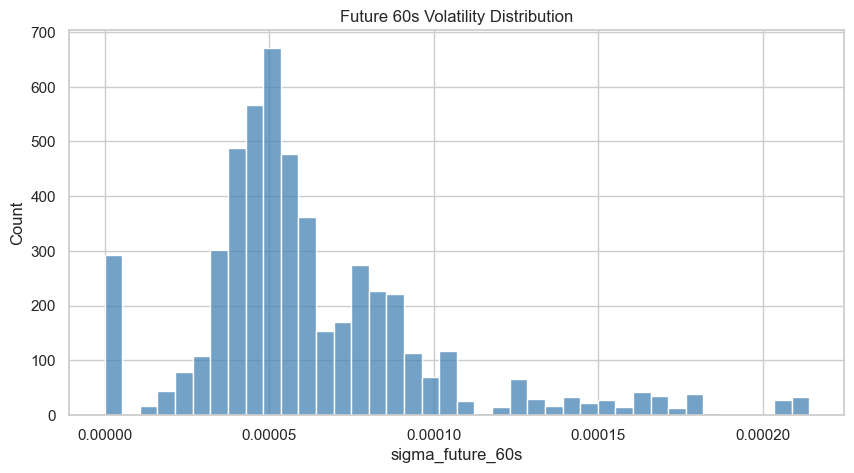

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(features['sigma_future_60s'].dropna(), bins=40, color='steelblue', ax=ax)
ax.set_title('Future 60s Volatility Distribution')
ax.set_xlabel('sigma_future_60s')
ax.set_ylabel('Count')
save_and_show(fig, 'eda_sigma_future_distribution.png')


The future-volatility label source should be right-skewed. The exact tail behavior matters because the threshold is defined from the upper quantiles.


,quantile,tau,positive_rate
0,0.80,0.000084,0.198546
1,0.85,0.000090,0.149197
2,0.90,0.000104,0.099273
3,0.95,0.000144,0.049732


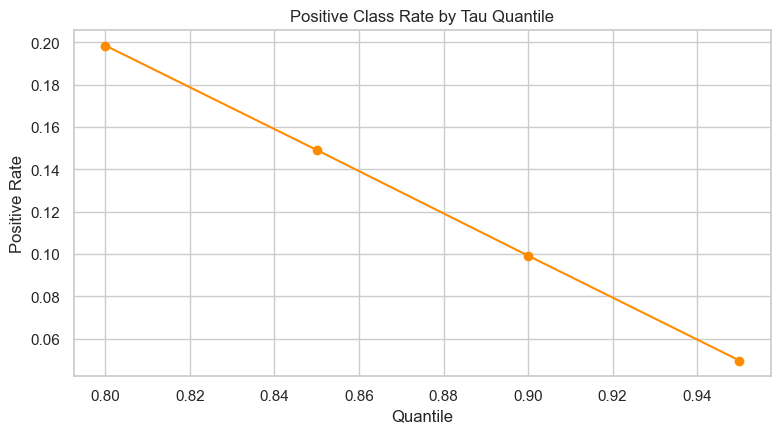

In [5]:
tau_candidates = features['sigma_future_60s'].quantile([0.80, 0.85, 0.90, 0.95]).rename('tau').reset_index()
tau_candidates.columns = ['quantile', 'tau']
tau_candidates['positive_rate'] = tau_candidates['tau'].apply(lambda t: float((features['sigma_future_60s'] >= t).mean()))
display(tau_candidates)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(tau_candidates['quantile'], tau_candidates['positive_rate'], marker='o', color='darkorange')
ax.set_title('Positive Class Rate by Tau Quantile')
ax.set_xlabel('Quantile')
ax.set_ylabel('Positive Rate')
save_and_show(fig, 'eda_tau_positive_rate.png')


This percentile sweep is the key threshold-selection step. The 90th percentile is the default unless it makes the event rate too sparse for a stable classifier.


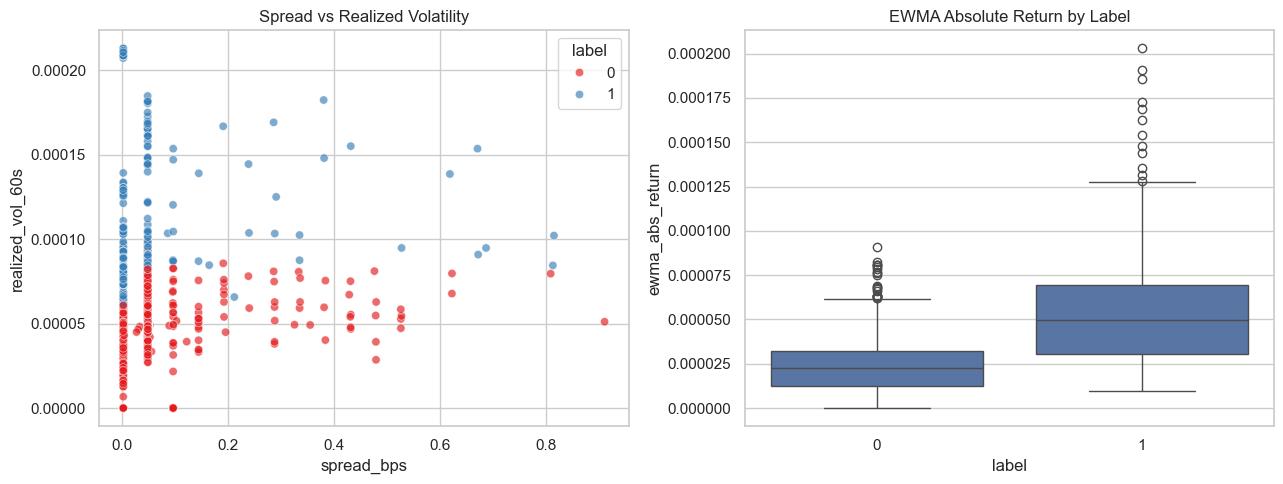

In [6]:
sample = features[['spread_bps', 'realized_vol_60s', 'ewma_abs_return', 'label']].dropna().sample(min(1000, len(features)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=sample, x='spread_bps', y='realized_vol_60s', hue='label', palette='Set1', alpha=0.65, ax=axes[0])
axes[0].set_title('Spread vs Realized Volatility')
sns.boxplot(data=sample, x='label', y='ewma_abs_return', ax=axes[1])
axes[1].set_title('EWMA Absolute Return by Label')
fig.tight_layout()
save_and_show(fig, 'eda_feature_relationships.png')


These feature relationships are a quick check that the positive label is at least directionally aligned with wider spreads and larger recent return magnitudes.


## Final Summary
- Confirm that the chosen `tau` produces a usable positive-class rate.
- Reuse the exported figures in `img/` for the model evaluation report.
- If label balance is unstable, revisit the tau percentile before training.
